# Train/val/test split, panel construction and feature engineering**

Two panels get built here:
1. **Severity panel** – one row per claim, used to train the repair-cost regression model.
2. **Choice panel** – one row per (claim, candidate garage), used to train the garage-selection model. Built by expanding every claim against its manufacturer's 100 candidate garages, with the actually-chosen garage labeled `1` and the rest `0`.

Both panels share the same claim-level train/val/test split so the two models are evaluated consistently and can be combined later without any train/test mixing.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

claims = pd.read_csv("data/claims_clean.csv")
garages = pd.read_csv("data/garages.csv")
potential = pd.read_csv("data/potential_garages_by_manufacturer.csv")

print(f"claims:    {claims.shape}")
print(f"garages:   {garages.shape}")
print(f"potential: {potential.shape}")

claims:    (2000, 25)
garages:   (150, 8)
potential: (2500, 2)


## Train / val / test split

Splitting **chronologically** by `event_date` (70/15/15) rather than randomly: train on the earliest claims, validate on the next slice, test on the most recent ones. This matches how the model will actually be used in production - always predicting on claims that happened after the ones it was trained on - and avoids a random split silently giving the model a look at "future" patterns during training.

The same claim-level split is then reused for both panels, so no claim's rows leak across train/val/test in the choice panel either.

In [18]:
claims = claims.sort_values("event_date").reset_index(drop=True)

n = len(claims)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

claims["split"] = "train"
claims.loc[train_end:val_end, "split"] = "val"
claims.loc[val_end:, "split"] = "test"

print(claims["split"].value_counts())
print()
print(claims.groupby("split")["event_date"].agg(["min", "max"]))

split
train    1400
val       300
test      300
Name: count, dtype: int64

              min         max
split                        
test   2025-09-09  2025-12-15
train  2024-01-01  2025-05-18
val    2025-05-20  2025-09-06


**Representation check.** A chronological split only works if it doesn't accidentally starve train/val/test of some category (e.g. one manufacturer only showing up late in the timeline). Checking the key categorical variables across splits before moving on.

In [19]:
check_cols = ["car_manufacturer", "damage_type", "insured_city_type", "insured_city_ses_cluster", "opened_by"]

for col in check_cols:
    print(f"--- {col} ---")
    print(pd.crosstab(claims[col], claims["split"], normalize="columns").round(3))
    print()

--- car_manufacturer ---
split              test  train    val
car_manufacturer                     
Audi              0.043  0.049  0.047
BMW               0.047  0.035  0.043
Chery             0.050  0.034  0.040
Chevrolet         0.040  0.040  0.027
Citroen           0.053  0.046  0.030
Ford              0.027  0.042  0.043
Geely             0.050  0.034  0.030
Honda             0.047  0.042  0.047
Hyundai           0.060  0.044  0.047
Kia               0.043  0.046  0.040
Mazda             0.057  0.039  0.033
Mercedes          0.037  0.036  0.050
Mitsubishi        0.040  0.035  0.040
Nissan            0.033  0.035  0.047
Opel              0.030  0.037  0.023
Peugeot           0.017  0.039  0.057
Renault           0.027  0.045  0.050
Seat              0.047  0.042  0.033
Skoda             0.043  0.033  0.043
Subaru            0.023  0.045  0.040
Suzuki            0.050  0.042  0.030
Tesla             0.027  0.037  0.057
Toyota            0.047  0.045  0.030
Volkswagen        0.030  

Distributions look consistent across splits for every variable - no manufacturer, damage type, or locality segment is meaningfully over/under-represented in any split. The synthetic data has no real seasonal or trend signal, so the chronological cut doesn't cost us anything in representation while giving a more realistic (out-of-time) evaluation setup.

## Severity panel

The severity model only needs claim-level features - it estimates expected repair cost independent of which garage ends up doing the work, since I don't have garage-level cost data to condition on. Feature set: vehicle characteristics, driver age, damage type, and insured location/SES context.

In [20]:
severity_features = [
    "vehicle_age", "vehicle_value_nis", "driver_age", "damage_type",
    "car_manufacturer", "insured_city_type", "insured_city_ses_cluster",
    "opened_by", "driver_age_was_imputed", "insured_lat_was_imputed",
]

severity_panel = claims[["claim_id", "split", "damage_cost_nis"] + severity_features].copy()
severity_panel["log_damage_cost"] = np.log1p(severity_panel["damage_cost_nis"])

print(severity_panel.shape)
severity_panel.head(3)

(2000, 14)


,claim_id,split,damage_cost_nis,vehicle_age,vehicle_value_nis,driver_age,damage_type,car_manufacturer,insured_city_type,insured_city_ses_cluster,opened_by,driver_age_was_imputed,insured_lat_was_imputed,log_damage_cost
0,982,train,12178.24,5,58817,36.0,collision,Chevrolet,suburban,8,agent,0,0,9.407488
1,137,train,7145.11,8,47366,49.0,weather,Mazda,urban,7,agent,0,0,8.874323
2,570,train,6518.21,16,36564,42.0,weather,Ford,urban,4,insured,0,0,8.782508


In [21]:
print(severity_panel.isnull().sum().sum(), "missing values in severity panel")
severity_panel.groupby("split")["damage_cost_nis"].agg(["count", "mean", "median"])

0 missing values in severity panel


,count,mean,median
split,,,
test,300,7993.907600,7684.995
train,1400,8155.837743,7732.455
val,300,8025.504900,7453.545


## Choice panel

For every claim I cross-join against the 100 garages in that claim's manufacturer's candidate list, and label the row `1` where it matches `chosen_garage_id`. This turns 2,000 claims into a 2,000 × 100 = 200,000-row panel, matching the "one positive out of a fixed candidate set" structure of a discrete-choice problem.

In [22]:
choice_panel = claims.merge(potential, on="car_manufacturer", how="left")
choice_panel = choice_panel.rename(columns={"garage_id": "candidate_garage_id"})
choice_panel = choice_panel.merge(
    garages, left_on="candidate_garage_id", right_on="garage_id", how="left", suffixes=("", "_garage")
)
choice_panel["chosen"] = (choice_panel["candidate_garage_id"] == choice_panel["chosen_garage_id"]).astype(int)

n_positives = choice_panel["chosen"].sum()
positive_rate = choice_panel["chosen"].mean()
print(choice_panel.shape)
print(f"positives: {n_positives} (expected {claims.shape[0]})")
print(f"positive rate: {positive_rate:.4%}")

(200000, 36)
positives: 2000 (expected 2000)
positive rate: 1.0000%


## Claim–garage interaction features

The features that actually distinguish one candidate from another for the same claim: geographic distance, socioeconomic gap between the insured's and the garage's locality, and whether the locality types match.

In [23]:
def haversine_km(lat1: np.ndarray, lon1: np.ndarray, lat2: np.ndarray, lon2: np.ndarray) -> np.ndarray:
    """Great-circle distance (km) between two points given lat/lon, vectorized."""
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


choice_panel["dist_km"] = haversine_km(
    choice_panel["insured_lat"], choice_panel["insured_lon"],
    choice_panel["garage_lat"], choice_panel["garage_lon"],
)
choice_panel["log_dist_km"] = np.log1p(choice_panel["dist_km"])
choice_panel["ses_delta"] = (choice_panel["insured_city_ses_cluster"] - choice_panel["garage_city_ses_cluster"]).abs()
choice_panel["city_type_match"] = (choice_panel["insured_city_type"] == choice_panel["garage_city_type"]).astype(int)

# rank of each candidate's distance within its own claim - cheap, purely geometric, no leakage risk
choice_panel["dist_rank"] = choice_panel.groupby("claim_id")["dist_km"].rank(method="first")

print(choice_panel["dist_km"].isnull().sum(), "missing distances")
choice_panel[["dist_km", "ses_delta", "city_type_match", "dist_rank"]].describe()

0 missing distances


,dist_km,ses_delta,city_type_match,dist_rank
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,170.392684,2.071605,0.436610,50.500000
std,97.675297,1.539717,0.495967,28.866142
min,0.000000,0.000000,0.000000,1.000000
25%,94.602589,1.000000,0.000000,25.750000
50%,154.359832,2.000000,0.000000,50.500000
75%,234.947959,3.000000,1.000000,75.250000
max,445.211717,8.000000,1.000000,100.000000


## Does proximity actually predict choice?

Quick sanity check before trusting distance as a feature: for each claim, what's the distance rank of the garage the customer actually picked?

count    2000.000000
mean        3.099500
std         4.185016
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        63.000000
Name: dist_rank, dtype: float64

share of claims where the chosen garage is the closest candidate: 44.0%
share within the 3 closest candidates: 75.6%


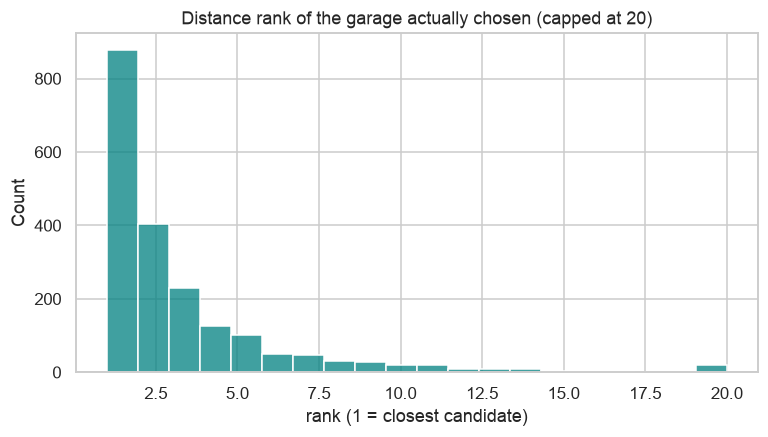

In [24]:
# chosen - all chosen garage (2000); dist_rank - the distance ranking (1 to 100) from a claim location to all 100 relevant garages
chosen_rank = choice_panel.loc[choice_panel["chosen"] == 1, "dist_rank"]

print(chosen_rank.describe())
print(f"\nshare of claims where the chosen garage is the closest candidate: {(chosen_rank == 1).mean():.1%}")
print(f"share within the 3 closest candidates: {(chosen_rank <= 3).mean():.1%}")

plt.figure(figsize=(8, 4))
sns.histplot(chosen_rank.clip(upper=20), bins=20, color="teal")
plt.title("Distance rank of the garage actually chosen (capped at 20)")
plt.xlabel("rank (1 = closest candidate)")
plt.show()

Strong signal: ~44% of customers pick the single closest candidate garage, and the large majority land in the top few by distance. `dist_km` / `dist_rank` should be among the most important features in the choice model.

## Garage popularity feature (leakage-safe)

A garage's general popularity for a given manufacturer - independent of any single claim's geography - is a useful prior (some garages just have a stronger reputation or more capacity). This has to be computed from the **train split only** and then applied to val/test, otherwise we'd be leaking the outcome we're trying to predict into the features.

In [25]:
train_panel = choice_panel[choice_panel["split"] == "train"]

# how popular is this garage among this manufacturer's customers, based on history
garage_share = (
    train_panel.groupby(["car_manufacturer", "candidate_garage_id"])["chosen"]
    .mean()
    .rename("garage_manufacturer_share")
)

fallback_share = train_panel["chosen"].mean()  # ~1/100, used for any garage unseen in train for that manufacturer

# Merges that train-only statistic onto the full panel (train+val+test)
choice_panel = choice_panel.merge(garage_share, on=["car_manufacturer", "candidate_garage_id"], how="left")
choice_panel["garage_manufacturer_share"] = choice_panel["garage_manufacturer_share"].fillna(fallback_share)

n_fallback = (choice_panel["garage_manufacturer_share"] == fallback_share).sum()
print(f"fallback share used for: {n_fallback} rows")
choice_panel["garage_manufacturer_share"].describe()

fallback share used for: 0 rows


count    200000.000000
mean          0.010000
std           0.014637
min           0.000000
25%           0.000000
50%           0.000000
75%           0.017857
max           0.101695
Name: garage_manufacturer_share, dtype: float64

## Final panel check

Confirming shapes, no unexpected nulls, and the split proportions carried over correctly from the claim-level split.

In [26]:
choice_features = [
    "dist_km", "log_dist_km", "dist_rank", "ses_delta", "city_type_match",
    "garage_manufacturer_share", "garage_city_type", "garage_city_ses_cluster",
    "insured_city_type", "insured_city_ses_cluster", "opened_by", "car_manufacturer",
]

choice_model_panel = choice_panel[
    ["claim_id", "candidate_garage_id", "split", "chosen"] + choice_features
].copy()

print(choice_model_panel.shape)
print(choice_model_panel.isnull().sum().sum(), "missing values")
choice_model_panel.groupby("split")["chosen"].agg(["count", "sum", "mean"])

(200000, 16)
0 missing values


,count,sum,mean
split,,,
test,30000,300,0.01
train,140000,1400,0.01
val,30000,300,0.01


## Saving both panels

Both go to parquet, ready for Step 3 (model training).

In [27]:
severity_panel.to_csv("data/severity_panel.csv", index=False)
choice_model_panel.to_csv("data/choice_panel.csv", index=False)

## Step 2 summary

- Split 2,000 claims 70/15/15 **chronologically** by `event_date` (out-of-time validation) and reused it across both panels, so no claim's rows leak across train/val/test in the choice model. Confirmed categorical representation (manufacturer, damage type, locality, SES) stays consistent across splits despite the time-based cut.
- Severity panel is a direct claim-level table (2,000 rows) with the log-transformed target ready for regression.
- Choice panel expands to 200,000 rows (2,000 claims × 100 candidates), with distance, SES gap, locality-type match, and a leakage-safe garage popularity prior as the key discriminating features.
- Early signal check confirms distance is highly predictive of the actual choice (~44% closest-candidate selection rate) - a good sanity check before modeling.

**Next (Step 3):** train the severity model (gradient boosting regressor) and the choice model (gradient boosting classifier on the panel), with light hyperparameter tuning and calibration checks.